In [ ]:
import os
from pathlib import Path

# ===== Step 1: Specify Input Folder =====
# Path to painting dataset (Chinese: huazuo)
folder = Path(r"C:\Users\asus\Desktop\RC11 TERM2\huazuo")
valid_ext = {".jpg", ".jpeg", ".png"}

# ===== Step 2: Collect and Sort Image Files =====
# Filter valid image formats, sort by filename
files = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in valid_ext]
files = sorted(files, key=lambda p: p.name.lower())

print(f"🔍 Found {len(files)} images, starting safe rename...")

# ===== Step 3: Two-Stage Rename - Temporary Names =====
# Phase 1: Rename to temporary names to avoid file conflicts
temp_files = []
for i, p in enumerate(files, 1):
    tmp = folder / f"__tmp__{i:04d}{p.suffix.lower()}"
    p.rename(tmp)
    temp_files.append(tmp)

# ===== Step 4: Final Rename to Sequential Numbers =====
# Phase 2: Rename to final format (1.jpg, 2.jpg, ...)
ok = 0
for i, p in enumerate(temp_files, 1):
    new_name = folder / f"{i}{p.suffix.lower()}"
    p.rename(new_name)
    ok += 1

print("-" * 30)
print("✨ Complete")
print(f"📊 Successfully renamed: {ok} files")
print(f"📂 Path: {folder}")


🔍 找到 1505 张图片，开始安全重命名...
------------------------------
✨ 完成
📊 成功重命名: 1505
📂 路径: C:\Users\asus\Desktop\RC11 TERM2\huazuo


# Chapter 1: Object Detection & Segmentation with YOLO & SAM

## Project Overview

This notebook implements an end-to-end pipeline for **intelligent image segmentation** combining:
- **YOLOv8**: State-of-the-art object detection for spatial awareness
- **Segment Anything Model (SAM)**: Fine-grained semantic segmentation
- **Language-SAM**: Text-guided segmentation for targeted object extraction

### Key Objectives
1. **Automated File Organization**: Batch rename and standardize image dataset
2. **Object Detection**: Identify key objects using YOLOv8
3. **Instance Segmentation**: Extract individual object masks with SAM
4. **Semantic Understanding**: Align text queries with visual regions
5. **Multi-Format Output**: Generate masks, contours, and visualization overlays

### Pipeline Architecture
```
Raw Image Dataset
     ↓
[Step 1] YOLO Detection → Bounding Boxes + Confidence
     ↓
[Step 2] SAM Instance Segmentation → Precise Masks
     ↓
[Step 3] Language-SAM → Text-Guided Filtering (Optional)
     ↓
Output: Annotated Images + Mask Arrays + Metadata
```

### Expected Outputs
1. **Detection Results**: YOLO predictions with bounding boxes
2. **Segmentation Masks**: Binary or multi-class instance masks
3. **Contour Drawings**: Polygon representations of detected objects
4. **Visualization Overlays**: Annotated images for quality validation

---

In [3]:
import sys
!{sys.executable} -m pip install torch torchvision
!{sys.executable} -m pip install -U git+https://github.com/lucasb-eyer/pydensecrf.git
!{sys.executable} -m pip install lang-sam

  Cloning https://github.com/lucasb-eyer/pydensecrf.git to C:\Users\asus\AppData\Local\Temp\pip-req-build-p1asxlms
  Resolved https://github.com/lucasb-eyer/pydensecrf.git to commit 2723c7fa4f2ead16ae1ce3d8afe977724bb8f87f
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pydensecrf


  Running command git clone --filter=blob:none --quiet https://github.com/lucasb-eyer/pydensecrf.git 'C:\Users\asus\AppData\Local\Temp\pip-req-build-p1asxlms'
  error: subprocess-exited-with-error
  
  × Building wheel for pydensecrf (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [22 lines of output]
      C:\Users\asus\AppData\Local\Temp\pip-build-env-kbp1747s\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: MIT License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ********************************************************************************
      
      !!

In [ ]:
import sys
print("Current kernel:", sys.executable)

# ===== Install Core Dependencies =====
!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install torch torchvision pillow numpy
!{sys.executable} -m pip install git+https://github.com/luca-medeiros/lang-segment-anything.git


当前内核: c:\ProgramData\miniconda3\envs\jupyter-py311\python.exe
  Cloning https://github.com/luca-medeiros/lang-segment-anything.git to C:\Users\asus\AppData\Local\Temp\pip-req-build-r3jkmf9c
  Resolved https://github.com/luca-medeiros/lang-segment-anything.git to commit 918043ed4666eea04da88aa179eb8d27ef4b1a1d
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Cloning https://github.com/facebookresearch/segment-anything-2 (to revision c2ec8e14a185632b0a5d8b161928ceb50197eddc) to C:\Users\asus\AppData\Local\Temp\pip-install-9h45z_4_\sam-2_adc366391a8a4a81982c9462e4cf197f
  Resolved https://github.com/facebookresearch/segment-anything-2 to commit c2ec8e14a185632b0a5d8b161928ceb50197eddc
  Installing build depende

  Running command git clone --filter=blob:none --quiet https://github.com/luca-medeiros/lang-segment-anything.git 'C:\Users\asus\AppData\Local\Temp\pip-req-build-r3jkmf9c'
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything-2 'C:\Users\asus\AppData\Local\Temp\pip-install-9h45z_4_\sam-2_adc366391a8a4a81982c9462e4cf197f'
  Running command git rev-parse -q --verify 'sha^c2ec8e14a185632b0a5d8b161928ceb50197eddc'
  Running command git fetch -q https://github.com/facebookresearch/segment-anything-2 c2ec8e14a185632b0a5d8b161928ceb50197eddc
  Running command git checkout -q c2ec8e14a185632b0a5d8b161928ceb50197eddc


In [ ]:
# ===== Verify LangSAM Import =====
from lang_sam import LangSAM
print("✅ LangSAM imported successfully")


c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


LangSAM 导入成功


In [3]:
import sys
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:


ERROR: Exception:
Traceback (most recent call last):
  File "c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\shutil.py", line 853, in move
    os.rename(src, real_dst)
PermissionError: [WinError 5] Access is denied: 'c:\\programdata\\miniconda3\\envs\\jupyter-py311\\lib\\site-packages\\torch\\lib\\' -> 'C:\\ProgramData\\miniconda3\\envs\\jupyter-py311\\Lib\\site-packages\\torch\\~ib'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\site-packages\pip\_internal\commands\uninstall.py", line 105, in 

Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 22.3 MB/s eta 0:02:07
   ---------------------------------------- 0.0/2.8 GB 22.5 MB/s eta 0:02:05
   ---------------------------------------- 0.0/2.8 GB 24.3 MB/s eta 0:01:56
   ---------------------------------------- 0.0/2.8 GB 25.2 MB/s eta 0:01:52
   ---------------------------------------- 0.0/2.8 GB 24.0 MB/s eta 0:01:57
   ---------------------------------------- 0.0/2.8 GB 24.6 MB/s eta 0:01:54
    --------------------------------------- 0.0/2.8 GB 25.4 MB/s eta 0:01:50
    --------------------------------------- 0.0/2.8 GB 26.3 MB/s eta 0:01:46
    --------------------------------------- 0.1/2.8 GB 26.7 MB/s eta 0:01:44
    --------------------------------------- 0.1/2.8 GB 27.1 MB/s eta 0:01:42
    --------------------------------------- 0.1/2.8 GB 27.2 MB/s eta 0:01:42
   - --------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.9.1 requires torch==2.9.1, but you have torch 2.7.1+cu118 which is incompatible.


Looking in indexes: https://download.pytorch.org/whl/cu124
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/6.1 MB ? eta -:--:--
   ---------------------------------------  6.0/6.1 MB 33.5 MB/s eta 0:00:01
   ---------------------------------------- 6.1/6.1 MB 20.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 GB 33.6 MB/s eta 0:01:16
   ---------------------------------------- 0.0/2.5 GB 32.9 MB/s eta 0:01:17
   ---------------------------------------- 0.0/2.5 GB 34.4 MB/s eta 0:01:14
   ---------------------------------------- 0.0/2.5 GB 35.5 MB/s eta 0:01:11
    --------------------------------------- 0.0/2

In [1]:
import sys
!{sys.executable} -m pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp311-cp311-win_amd64.whl.metadata (27 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached numpy-2.3.5-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached pillow-12.0.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp311-cp311-win_amd64.whl (2817.2 MB)
Using cached https://download-r2.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp311-cp311-win_amd64.whl (5.5 MB)
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
 

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moviepy 2.2.1 requires pillow<12.0,>=9.2.0, but you have pillow 12.0.0 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.


In [ ]:
# ===== Check PyTorch and GPU Status =====
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


2.7.1+cu118
CUDA可用: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [ ]:
# ===== Verify SAM Model Checkpoint Location =====
from pathlib import Path

checkpoint_path = Path(r"C:\Users\asus\Desktop\RC11 TERM2\sam_vit_h_4b8939.pth")
print("File exists:", checkpoint_path.exists())
print("Absolute path:", checkpoint_path.resolve())


存在吗: False
绝对路径: C:\Users\asus\Desktop\RC11 TERM2\sam_vit_h_4b8939.pth


In [ ]:
# ===== Search for SAM Model Checkpoint Across System =====
from pathlib import Path

candidates = []
for root in [Path(r"C:\Users\asus\Desktop"), Path(r"C:\Users\asus\Downloads"), Path(r"C:\Users\asus")]:
    try:
        candidates += list(root.rglob("sam_vit_h_4b8939.pth"))
    except Exception:
        pass

print("Found count:", len(candidates))
for p in candidates[:20]:
    print(p)


找到数量: 0


In [ ]:
# ===== Install Segment Anything from Facebook Research =====
!pip install git+https://github.com/facebookresearch/segment-anything.git


  Cloning https://github.com/facebookresearch/segment-anything.git to C:\Users\asus\AppData\Local\Temp\pip-req-build-heglm2w2
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\asus\AppData\Local\Temp\pip-req-build-heglm2w2'


In [ ]:
import os
import torch
import numpy as np
from PIL import Image
from pathlib import Path
from lang_sam import LangSAM 
from segment_anything import SamAutomaticMaskGenerator

# ===== Section 1: Stability and Performance Configuration =====
# Enable high precision matrix multiplication and TF32 acceleration
torch.set_float32_matmul_precision("high")
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# ===== Section 2: Path Configuration =====
input_folder = Path(r"C:\Users\asus\Desktop\RC11 TERM2\huazuo")
output_root = Path(r"C:\Users\asus\Desktop\RC11 TERM2\asset_library_window_priority_final")
output_root.mkdir(parents=True, exist_ok=True)

# Significance threshold: fragments must occupy >5% of image
MIN_NEW_AREA_RATIO = 0.05 

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Device: {device} | Mode: Semantic Priority + Force FP32")

# ===== Section 3: Initialize Inference Engine (with Precision Fix) =====
print("🧠 Loading engine...")
model_engine = LangSAM()

# --- KEY FIX: Force all internal models to float32 to prevent BF16 errors ---
model_engine.sam.to(device)
model_engine.grounding_dino.to(device)
model_engine.sam.float() 
model_engine.grounding_dino.float()

# ===== Section 4: Initialize Automatic Mask Generator =====
# Generate all candidate masks across the image
mask_generator = SamAutomaticMaskGenerator(
    model=model_engine.sam,
    points_per_side=16,          # Acceleration: reduce sampling points
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    min_mask_region_area=2000
)

# ===== Section 5: Main Extraction Pipeline =====
image_files = sorted([p for p in input_folder.iterdir() if p.suffix.lower() in [".png",".jpg",".jpeg"]], key=lambda x: x.name.lower())

for i, img_path in enumerate(image_files, 1):
    try:
        with Image.open(img_path) as img:
            # Resize to prevent memory overflow
            img.thumbnail((1024, 1024))
            image_pill = img.convert("RGB")
            image_np = np.array(image_pill, dtype=np.uint8)
            h, w, _ = image_np.shape
            
            occupied_mask = np.zeros((h, w), dtype=bool)
            extracted_count = 0

            # Use inference_mode to save GPU memory, disable autocast to force FP32
            with torch.inference_mode():
                with torch.cuda.amp.autocast(enabled=False):
                    
                    # --- Step 1: Detect Windows (Semantic Priority) ---
                    try:
                        # FIX: Add period to prompt to resolve dimension mismatch
                        w_masks, _, _, _ = model_engine.predict(image_pill, "window .")
                        
                        if w_masks is not None and len(w_masks) > 0:
                            w_m = w_masks[0].cpu().numpy().astype(bool)
                            
                            # Create RGBA with alpha channel for transparency
                            rgba_w = np.zeros((h, w, 4), dtype=np.uint8)
                            rgba_w[:, :, :3] = image_np
                            rgba_w[:, :, 3] = (w_m * 255).astype(np.uint8)
                            
                            # Find bounding box of detected region
                            coords_w = np.argwhere(w_m)
                            if coords_w.size > 0:
                                y_min, x_min = coords_w.min(axis=0); y_max, x_max = coords_w.max(axis=0)
                                Image.fromarray(rgba_w).crop((x_min, y_min, x_max, y_max)).save(
                                    output_root / f"{img_path.stem}_piece_0_WINDOW.png")
                                
                                occupied_mask |= w_m
                                extracted_count = 1
                                print(f"   ✨ {img_path.name}: Window extracted")
                        else:
                            print(f"   ℹ️ {img_path.name}: No prominent window detected")
                    except Exception as e_inner:
                        print(f"   ⚠️ Window search skipped: {e_inner}")

                    # --- Step 2: Automatic Instance Segmentation ---
                    # Generate all candidate masks using SAM
                    masks = mask_generator.generate(image_np)
                    sorted_masks = sorted(masks, key=lambda x: x["area"], reverse=True)

                    # Extract each non-overlapping mask
                    for m_data in sorted_masks:
                        seg = m_data["segmentation"].astype(bool)
                        final_mask = seg & (~occupied_mask) # Exclude already extracted regions
                        
                        # Skip fragments smaller than threshold
                        if (np.sum(final_mask) / (h * w)) < MIN_NEW_AREA_RATIO:
                            continue

                        # Create RGBA output with alpha channel
                        rgba_f = np.zeros((h, w, 4), dtype=np.uint8)
                        rgba_f[:, :, :3] = image_np
                        rgba_f[:, :, 3] = (final_mask * 255).astype(np.uint8)

                        # Get bounding box and crop
                        coords_f = np.argwhere(final_mask)
                        if coords_f.size == 0: continue
                        y_min, x_min = coords_f.min(axis=0); y_max, x_max = coords_f.max(axis=0)

                        # Save cropped piece
                        Image.fromarray(rgba_f).crop((x_min, y_min, x_max, y_max)).save(
                            output_root / f"{img_path.stem}_piece_{extracted_count}.png")
                        
                        occupied_mask |= seg
                        extracted_count += 1

        if device == "cuda": torch.cuda.empty_cache()
        print(f"[{i}/{len(image_files)}] ✅ Complete: {img_path.name}")

    except Exception as e:
        print(f"[{i}/{len(image_files)}] ❌ Error {img_path.name}: {e}")

print(f"\n✨ Pipeline complete! Extracted pieces saved to: {output_root}")


🚀 设备: cuda | 模式: 语义优先 + 强制 FP32
🧠 正在装载引擎...
One or both local paths not provided. Loading from Hugging Face Hub: IDEA-Research/grounding-dino-base


AttributeError: 'SAM' object has no attribute 'to'

In [ ]:
# ===== Install Advanced Segmentation Tools =====
# YOLO-World: Real-time object detection with vocabulary expansion
!pip install ultralytics

# SAM 2: Second generation Segment Anything Model
!pip install git+https://github.com/facebookresearch/sam2.git

# Supervision: Efficient detection box and mask processing library
!pip install supervision


  Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moviepy 2.2.1 requires pillow<12.0,>=9.2.0, but you have pillow 12.0.0 which is incompatible.


  Cloning https://github.com/facebookresearch/sam2.git to C:\Users\asus\AppData\Local\Temp\pip-req-build-e1a9v6hj
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git 'C:\Users\asus\AppData\Local\Temp\pip-req-build-e1a9v6hj'


In [ ]:
# ===== Clone and Install SAM2 from Official Repository =====
# Step 1: Clone the repository
!git clone https://github.com/facebookresearch/sam2.git

# Step 2: Navigate into directory (use %cd for Jupyter notebook)
%cd sam2

# Step 3: Install SAM 2 and dependencies in development mode
!pip install -e .

# Step 4: Return to parent directory (where images and weights are located)
%cd ..


c:\Users\asus\Desktop\RC11 TERM2\sam2


Cloning into 'sam2'...


Obtaining file:///C:/Users/asus/Desktop/RC11%20TERM2/sam2
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for SAM-2 (pyproject.toml): started
  Building editable for SAM-2 (pyproject.toml): finished with status 'done'
  Created wheel for SAM-2: filename=sam_2-1.0-0.editable-py3-none-any.whl size=13932 sha256=81f259ecb8fd7537d6e9f9b3aee40e44468d7fe48b78164a502f110547c84aba
  Stored in directory: C:\Users\asus\AppData\Local\Temp\pip-ephem-wheel-cache-ldgkdm3c\wheels\19\1b\0c\0dd9c77e76d9a83fefcfe9bebbb5bb166d07c9dbebf5d696ac
Suc

In [ ]:
# ===== Verify SAM2 Installation =====
import sam2
print("✅ SAM 2 installed successfully!")


SAM 2 安装成功！


In [ ]:
# ===== Section: Train Custom YOLO Model for Window Detection =====
from ultralytics import YOLO
import os

# 1. Path to dataset configuration file
# Use r'' raw string to avoid backslash escaping issues on Windows
data_yaml_path = r"C:\Users\asus\Desktop\RC11 TERM2\yolo\data.yaml"

# 2. Load base model (Nano version optimal for quick fine-tuning of specific objects)
model = YOLO('yolov8n.pt') 

# 3. Start training: maximize RTX 3060 performance
results = model.train(
    data=data_yaml_path,
    epochs=50,              # 50 epochs, RTX 3060 handles 100+ images in about 8-10 minutes
    imgsz=640,             # Training resolution
    device=0,              # 0 = use first GPU (RTX 3060)
    batch=16,              # Batch size of 16 is stable for 3060 VRAM
    name='twincity_windows',# Folder name for results
    exist_ok=True          # Overwrite existing folder
)

print("\n" + "="*30)
print("✨ Training Complete!")
print(f"🚀 Your custom window detector model saved at:")
print(os.path.join(os.getcwd(), 'runs', 'detect', 'twincity_windows', 'weights', 'best.pt'))
print("="*30)


Obtaining file:///C:/Users/asus/Desktop/RC11%20TERM2/sam2
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for SAM-2 (pyproject.toml): started
  Building editable for SAM-2 (pyproject.toml): finished with status 'done'
  Created wheel for SAM-2: filename=sam_2-1.0-0.editable-py3-none-any.whl size=13932 sha256=5e0838496933a36817067efcf20e66c2751e5ab73b12ac892026d193c4eb111c
  Stored in directory: C:\Users\asus\AppData\Local\Temp\pip-ephem-wheel-cache-oc20xsls\wheels\19\1b\0c\0dd9c77e76d9a83fefcfe9bebbb5bb166d07c9dbebf5d696ac
Suc

In [2]:
import os
import sys

# ================= 0. 破除 Meta 的路径安全锁 =================
# 强行让 Jupyter 走进 sam2 文件夹内部，避开官方的同名冲突报错
repo_dir = r"C:\Users\asus\Desktop\RC11 TERM2\sam2"
os.chdir(repo_dir)

# 现在可以安全导入了！
import torch
import numpy as np
from PIL import Image
from pathlib import Path
from ultralytics import YOLOWorld
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

# ================= 1. 路径与配置 (已适配 SAM 2.1) =================
yolo_path = r"C:\Users\asus\Desktop\RC11 TERM2\yolov8s-worldv2.pt"
sam2_path = r"C:\Users\asus\Desktop\RC11 TERM2\sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml" 

input_folder = Path(r"C:\Users\asus\Desktop\RC11 TERM2\huazuo")
output_root = Path(r"C:\Users\asus\Desktop\RC11 TERM2\asset_library_twincity_sam2.1")
output_root.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
MIN_NEW_AREA_RATIO = 0.05  

# 稳定性护盾：防止 3060 出现 BFloat16 报错
torch.set_float32_matmul_precision("high")

# ================= 2. 初始化双引擎 =================
print("🧠 正在装载 YOLO-World 雷达与 SAM 2.1 引擎...")

# 引擎 A: YOLO-World (只抓窗户)
yolo_model = YOLOWorld(yolo_path)
yolo_model.set_classes(["window"]) 

# 引擎 B: SAM 2.1 (精准抠图)
sam2_model = build_sam2(model_cfg, sam2_path, device=device)
predictor = SAM2ImagePredictor(sam2_model)
mask_generator = SAM2AutomaticMaskGenerator(sam2_model, points_per_side=16)

# ================= 3. 执行全自动 1500 张拆解 =================
image_files = sorted([p for p in input_folder.iterdir() if p.suffix.lower() in [".png",".jpg",".jpeg"]], key=lambda x: x.name.lower())

print(f"🚀 Twin City 空间重构任务启动！共处理 {len(image_files)} 张历史画作...")

for i, img_path in enumerate(image_files, 1):
    try:
        with Image.open(img_path) as img:
            img.thumbnail((1024, 1024))
            img_rgb = img.convert("RGB")
            img_np = np.array(img_rgb)
            h, w, _ = img_np.shape
            
            occupied_mask = np.zeros((h, w), dtype=bool)
            extracted_count = 0

            with torch.inference_mode():
                # --- 阶段 1：YOLO 锁定窗户 ---
                yolo_results = yolo_model.predict(img_rgb, conf=0.15, verbose=False)[0]
                
                if len(yolo_results.boxes) > 0:
                    predictor.set_image(img_np)
                    box = yolo_results.boxes.xyxy.cpu().numpy()[0:1]
                    
                    w_masks, _, _ = predictor.predict(box=box, multimask_output=False)
                    w_m = w_masks[0].astype(bool)
                    
                    rgba_w = np.zeros((h, w, 4), dtype=np.uint8)
                    rgba_w[:, :, :3] = img_np
                    rgba_w[:, :, 3] = (w_m * 255).astype(np.uint8)
                    
                    coords = np.argwhere(w_m)
                    if coords.size > 0:
                        y_min, x_min = coords.min(axis=0); y_max, x_max = coords.max(axis=0)
                        Image.fromarray(rgba_w).crop((x_min, y_min, x_max, y_max)).save(
                            output_root / f"{img_path.stem}_piece_0_WINDOW.png")
                        
                        occupied_mask |= w_m
                        extracted_count = 1

                # --- 阶段 2：SAM 2.1 自动补全剩余拼图块 ---
                auto_masks = mask_generator.generate(img_np)
                sorted_masks = sorted(auto_masks, key=lambda x: x["area"], reverse=True)

                for m_data in sorted_masks:
                    seg = m_data["segmentation"].astype(bool)
                    final_mask = seg & (~occupied_mask)
                    
                    if (np.sum(final_mask) / (h * w)) < MIN_NEW_AREA_RATIO:
                        continue

                    rgba_f = np.zeros((h, w, 4), dtype=np.uint8)
                    rgba_f[:, :, :3] = img_np
                    rgba_f[:, :, 3] = (final_mask * 255).astype(np.uint8)

                    coords_f = np.argwhere(final_mask)
                    if coords_f.size == 0: continue
                    y_min, x_min = coords_f.min(axis=0); y_max, x_max = coords_f.max(axis=0)

                    Image.fromarray(rgba_f).crop((x_min, y_min, x_max, y_max)).save(
                        output_root / f"{img_path.stem}_piece_{extracted_count}.png")
                    
                    occupied_mask |= seg
                    extracted_count += 1

        if device == "cuda": torch.cuda.empty_cache()
        print(f"[{i}/{len(image_files)}] ✅ {img_path.name} -> 提取了 {extracted_count} 块碎片")

    except Exception as e:
        print(f"[{i}/{len(image_files)}] ❌ 出错 {img_path.name}: {e}")

print(f"\n✨ 破壁成功！收割任务顺利完成。")

RuntimeError: You're likely running Python from the parent directory of the sam2 repository (i.e. the directory where https://github.com/facebookresearch/sam2 is cloned into). This is not supported since the `sam2` Python package could be shadowed by the repository name (the repository is also named `sam2` and contains the Python package in `sam2/sam2`). Please run Python from another directory (e.g. from the repo dir rather than its parent dir, or from your home directory) after installing SAM 2.

In [1]:
# 没有任何 hack，直接干净利落地导入！
import torch
import numpy as np
from PIL import Image
from pathlib import Path
from ultralytics import YOLOWorld
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

print("🎉 恭喜！物理隔离成功，组件完美导入！")

# ================= 1. 路径与配置 =================
yolo_path = r"C:\Users\asus\Desktop\RC11 TERM2\yolov8s-worldv2.pt"
sam2_path = r"C:\Users\asus\Desktop\RC11 TERM2\sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml" 

input_folder = Path(r"C:\Users\asus\Desktop\RC11 TERM2\huazuo")
output_root = Path(r"C:\Users\asus\Desktop\RC11 TERM2\asset_library_twincity_sam2.1")
output_root.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
MIN_NEW_AREA_RATIO = 0.05  

torch.set_float32_matmul_precision("high")

# ================= 2. 初始化双引擎 =================
print("🧠 正在装载 YOLO-World 雷达与 SAM 2.1 引擎...")

yolo_model = YOLOWorld(yolo_path)
yolo_model.set_classes(["window"]) 

sam2_model = build_sam2(model_cfg, sam2_path, device=device)
predictor = SAM2ImagePredictor(sam2_model)
mask_generator = SAM2AutomaticMaskGenerator(sam2_model, points_per_side=16)

# ================= 3. 执行全自动 1500 张拆解 =================
image_files = sorted([p for p in input_folder.iterdir() if p.suffix.lower() in [".png",".jpg",".jpeg"]], key=lambda x: x.name.lower())

print(f"🚀 Twin City 空间重构任务启动！共处理 {len(image_files)} 张历史画作...")

for i, img_path in enumerate(image_files, 1):
    try:
        with Image.open(img_path) as img:
            img.thumbnail((1024, 1024))
            img_rgb = img.convert("RGB")
            img_np = np.array(img_rgb)
            h, w, _ = img_np.shape
            
            occupied_mask = np.zeros((h, w), dtype=bool)
            extracted_count = 0

            with torch.inference_mode():
                # --- 阶段 1：YOLO 锁定窗户 ---
                yolo_results = yolo_model.predict(img_rgb, conf=0.15, verbose=False)[0]
                
                if len(yolo_results.boxes) > 0:
                    predictor.set_image(img_np)
                    box = yolo_results.boxes.xyxy.cpu().numpy()[0:1]
                    
                    w_masks, _, _ = predictor.predict(box=box, multimask_output=False)
                    w_m = w_masks[0].astype(bool)
                    
                    rgba_w = np.zeros((h, w, 4), dtype=np.uint8)
                    rgba_w[:, :, :3] = img_np
                    rgba_w[:, :, 3] = (w_m * 255).astype(np.uint8)
                    
                    coords = np.argwhere(w_m)
                    if coords.size > 0:
                        y_min, x_min = coords.min(axis=0); y_max, x_max = coords.max(axis=0)
                        Image.fromarray(rgba_w).crop((x_min, y_min, x_max, y_max)).save(
                            output_root / f"{img_path.stem}_piece_0_WINDOW.png")
                        
                        occupied_mask |= w_m
                        extracted_count = 1

                # --- 阶段 2：SAM 2.1 自动补全 ---
                auto_masks = mask_generator.generate(img_np)
                sorted_masks = sorted(auto_masks, key=lambda x: x["area"], reverse=True)

                for m_data in sorted_masks:
                    seg = m_data["segmentation"].astype(bool)
                    final_mask = seg & (~occupied_mask)
                    
                    if (np.sum(final_mask) / (h * w)) < MIN_NEW_AREA_RATIO:
                        continue

                    rgba_f = np.zeros((h, w, 4), dtype=np.uint8)
                    rgba_f[:, :, :3] = img_np
                    rgba_f[:, :, 3] = (final_mask * 255).astype(np.uint8)

                    coords_f = np.argwhere(final_mask)
                    if coords_f.size == 0: continue
                    y_min, x_min = coords_f.min(axis=0); y_max, x_max = coords_f.max(axis=0)

                    Image.fromarray(rgba_f).crop((x_min, y_min, x_max, y_max)).save(
                        output_root / f"{img_path.stem}_piece_{extracted_count}.png")
                    
                    occupied_mask |= seg
                    extracted_count += 1

        if device == "cuda": torch.cuda.empty_cache()
        print(f"[{i}/{len(image_files)}] ✅ {img_path.name} -> 提取 {extracted_count} 块")

    except Exception as e:
        print(f"[{i}/{len(image_files)}] ❌ 出错 {img_path.name}: {e}")

print(f"\n✨ 大功告成！碎片生成完毕。")

🎉 恭喜！物理隔离成功，组件完美导入！
🧠 正在装载 YOLO-World 雷达与 SAM 2.1 引擎...
🚀 Twin City 空间重构任务启动！共处理 1505 张历史画作...
[1/1505] ✅ 1.jpg -> 提取 0 块
[2/1505] ✅ 10.jpg -> 提取 2 块
[3/1505] ✅ 100.jpg -> 提取 0 块
[4/1505] ✅ 1000.jpg -> 提取 0 块
[5/1505] ✅ 1001.jpg -> 提取 0 块
[6/1505] ✅ 1002.jpg -> 提取 1 块
[7/1505] ✅ 1003.jpg -> 提取 0 块
[8/1505] ✅ 1004.jpg -> 提取 1 块
[9/1505] ✅ 1005.jpg -> 提取 0 块
[10/1505] ✅ 1006.jpg -> 提取 0 块
[11/1505] ✅ 1007.jpg -> 提取 0 块
[12/1505] ✅ 1008.jpg -> 提取 0 块
[13/1505] ✅ 1009.jpg -> 提取 1 块
[14/1505] ✅ 101.jpg -> 提取 0 块
[15/1505] ✅ 1010.jpg -> 提取 2 块
[16/1505] ✅ 1011.jpg -> 提取 0 块
[17/1505] ✅ 1012.jpg -> 提取 0 块
[18/1505] ✅ 1013.jpg -> 提取 0 块
[19/1505] ✅ 1014.jpg -> 提取 1 块
[20/1505] ✅ 1015.jpg -> 提取 0 块
[21/1505] ✅ 1016.jpg -> 提取 0 块
[22/1505] ✅ 1017.jpg -> 提取 0 块
[23/1505] ✅ 1018.jpg -> 提取 1 块
[24/1505] ✅ 1019.jpg -> 提取 0 块
[25/1505] ✅ 102.jpg -> 提取 0 块
[26/1505] ✅ 1020.jpg -> 提取 1 块
[27/1505] ✅ 1021.jpg -> 提取 2 块
[28/1505] ✅ 1022.jpg -> 提取 0 块
[29/1505] ✅ 1023.jpg -> 提取 4 块
[30/1505] ✅ 1024.jpg ->

KeyboardInterrupt: 

In [2]:
from ultralytics import YOLO
import os

# 1. 指向你刚才解压的配置文件
# 使用 r'' 原始字符串确保 Windows 路径不会因为斜杠报错
data_yaml_path = r"C:\Users\asus\Desktop\RC11 TERM2\yolo\data.yaml"

# 2. 加载基础模型 (Nano 版本最适合这种特定物体的快速微调)
model = YOLO('yolov8n.pt') 

# 3. 启动训练：让 3060 显卡全速运转
results = model.train(
    data=data_yaml_path,
    epochs=50,              # 50 轮训练，你的 3060 跑这 100 多张图大约只需 8-10 分钟
    imgsz=640,             # 训练分辨率
    device=0,              # 0 表示使用你的第一块显卡 (RTX 3060)
    batch=16,              # 3060 显存充足，16 是很稳定的数值
    name='twincity_windows',# 结果存放的文件夹名
    exist_ok=True          # 覆盖同名文件夹
)

print("\n" + "="*30)
print("✨ 炼丹大功告成！")
print(f"🚀 你的专属『窗户收割机』模型已保存在：")
print(os.path.join(os.getcwd(), 'runs', 'detect', 'twincity_windows', 'weights', 'best.pt'))
print("="*30)

c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


New https://pypi.org/project/ultralytics/8.4.23 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.232  Python-3.11.14 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\asus\Desktop\RC11 TERM2\yolo\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name

In [ ]:
# ===== Test Trained Model on Sample Images =====
from ultralytics import YOLO
import os

# 1. Load your trained model
model_path = r'c:\Users\asus\Desktop\RC11 TERM2\My_Code\runs\detect\twincity_windows\weights\best.pt'
model = YOLO(model_path)

# 2. Prepare test image list
test_images = [
    r"C:\Users\asus\Desktop\RC11 TERM2\huazuo\3.jpg",
    r"C:\Users\asus\Desktop\RC11 TERM2\huazuo\435.jpg",
    r"C:\Users\asus\Desktop\RC11 TERM2\huazuo\445.jpg",
    r"C:\Users\asus\Desktop\RC11 TERM2\huazuo\597.jpg"
]

# 3. Execute prediction
# conf=0.25: Model triggers detection box if 25% confident it's a window
# Lower value = catch more (higher recall), Higher value = fewer false positives
results = model.predict(
    source=test_images, 
    save=True,          # Auto-save annotated images
    conf=0.25,          # Confidence threshold
    name='yanhuo_test', # Output folder name
    exist_ok=True       # Overwrite old results
)

print("\n" + "="*30)
print("✨ Test Prediction Complete!")
# Default Ultralytics storage location
print(f"📂 View results in:")
print(os.path.join(os.getcwd(), 'runs', 'detect', 'yanhuo_test'))
print("="*30)



0: 640x640 1 window, 17.7ms
1: 640x640 1 window, 17.7ms
2: 640x640 4 windows, 17.7ms
3: 640x640 2 windows, 17.7ms
Speed: 42.7ms preprocess, 17.7ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\asus\Desktop\RC11 TERM2\My_Code\runs\detect\yanhuo_test

✨ 验货预测完成！
📂 请去这个文件夹查看效果图：
c:\Users\asus\Desktop\RC11 TERM2\My_Code\runs\detect\yanhuo_test


In [ ]:
import os
import hashlib
import shutil

# ===== Section 1: Path Configuration =====
src_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo"
dup_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo_duplicates"

# Create duplicate folder if it doesn't exist
if not os.path.exists(dup_folder):
    os.makedirs(dup_folder)

def get_file_hash(file_path):
    """Calculate MD5 hash - unique 'fingerprint' for file identification"""
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()

# ===== Section 2: Scan and Remove Duplicates =====
seen_hashes = {}
dup_count = 0

print("🚀 Starting duplicate image scan...")

for filename in os.listdir(src_folder):
    # Process common image formats only
    if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
        file_path = os.path.join(src_folder, filename)
        
        file_hash = get_file_hash(file_path)
        
        if file_hash in seen_hashes:
            # Duplicate found! Move to duplicate folder
            print(f"[-] Duplicate detected: {filename} (same as {seen_hashes[file_hash]})")
            shutil.move(file_path, os.path.join(dup_folder, filename))
            dup_count += 1
        else:
            # First encounter - record fingerprint
            seen_hashes[file_hash] = filename

print(f"\n✨ Cleanup Complete! Moved {dup_count} duplicate images.")
print(f"📂 Duplicates folder: {dup_folder}")


🚀 开始扫描重复图片...

✨ 清理完成！共移走了 0 张重复图片。
📂 重复的图都放在了：C:\Users\asus\Desktop\RC11 TERM2\huazuo_duplicates


In [ ]:
# ===== Install Web Scraping Tools =====
# Note: In Jupyter, add ! prefix before pip commands
!pip install icrawler


  Using cached icrawler-0.6.10-py3-none-any.whl.metadata (6.2 kB)
  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
Using cached icrawler-0.6.10-py3-none-any.whl (36 kB)
Using cached bs4-0.0.2-py2.py3-none-any.whl (1.2 kB)

   ---------------------------------------- 2/2 [icrawler]



In [ ]:
from icrawler.builtin import BingImageCrawler
import os

# ===== Section 1: Configure Output Path =====
save_path = r'C:\Users\asus\Desktop\RC11 TERM2\huazuo_300'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# ===== Section 2: Define Search Queries (Each category searches for 100 images) =====
queries = [
    '19th century interior window oil painting', # Classic 19th-century window paintings with optimal lighting
    'Dutch Golden Age room window painting',      # Dutch Golden Age (exceptional light/shadow mastery)
    'Impressionist indoor window scene artwork'    # Impressionist works (improves model recognition of blurred edges)
]

# ===== Section 3: Start Web Crawling =====
for i, query in enumerate(queries):
    print(f"Round {i+1}/3: Harvesting... Query: {query}")
    # Set 4 threads for balanced speed (avoids getting blocked)
    crawler = BingImageCrawler(
        downloader_threads=4, 
        storage={'root_dir': os.path.join(save_path, f'batch_{i}')}
    )
    # Harvest 100 images per category
    crawler.crawl(keyword=query, max_num=100)

print(f"\n✨ 300 training images ready! Check folder: {save_path}")


正在进行第 1/3 轮收割，关键词: 19th century interior window oil painting


ERROR:downloader:Response status code 403, file https://image.invaluable.com/housePhotos/ogallerie/47/429647/H0060-L49925023.jpg


正在进行第 2/3 轮收割，关键词: Dutch Golden Age room window painting


ERROR:downloader:Response status code 403, file https://www.open.edu/openlearn/pluginfile.php/801880/mod_oucontent/oucontent/40676/4f5b4494/605c7310/a226_bk2_ch2_fig004.small.jpg
ERROR:downloader:Response status code 403, file https://www.open.edu/openlearn/pluginfile.php/801880/mod_oucontent/oucontent/40676/4f5b4494/20da30be/a226_bk2_ch2_fig002.small.jpg
ERROR:downloader:Response status code 404, file https://qatarmuseumsstorageprd.blob.core.windows.net/media/images/the-golden-age-exhibition-mia.2e16d0ba.fill-1200x630.jpg
ERROR:downloader:Response status code 403, file https://www.open.edu/openlearn/pluginfile.php/798689/tool_ocwmanage/image/0/a226_2_OLHP_786x400.jpg
ERROR:downloader:Response status code 403, file https://cloudflare1.360gigapixels.com/pano/prorama/01293206_stained_glass.jpg
ERROR:downloader:Response status code 403, file https://c.pxhere.com/photos/da/88/stained_glass_classical_classic_window_architecture_old-1215565.jpg
ERROR:downloader:Exception caught when download

正在进行第 3/3 轮收割，关键词: Impressionist indoor window scene artwork


ERROR:downloader:Exception caught when downloading file https://d1inegp6v2yuxm.cloudfront.net/royal-academy/image/upload/c_fill,cs_tinysrgb,dn_72,f_auto,fl_progressive.keep_iptc,w_952,h_535,ar_16:9/zpieedmp4gqa9owaocv4.jpg, error: HTTPSConnectionPool(host='d1inegp6v2yuxm.cloudfront.net', port=443): Max retries exceeded with url: /royal-academy/image/upload/c_fill,cs_tinysrgb,dn_72,f_auto,fl_progressive.keep_iptc,w_952,h_535,ar_16:9/zpieedmp4gqa9owaocv4.jpg (Caused by NameResolutionError("HTTPSConnection(host='d1inegp6v2yuxm.cloudfront.net', port=443): Failed to resolve 'd1inegp6v2yuxm.cloudfront.net' ([Errno 11001] getaddrinfo failed)")), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://d1inegp6v2yuxm.cloudfront.net/royal-academy/image/upload/c_fill,cs_tinysrgb,dn_72,f_auto,fl_progressive.keep_iptc,w_952,h_535,ar_16:9/zpieedmp4gqa9owaocv4.jpg, error: HTTPSConnectionPool(host='d1inegp6v2yuxm.cloudfront.net', port=443): Max retries exceeded with ur


✨ 300 张素材已就位！请去文件夹查看：C:\Users\asus\Desktop\RC11 TERM2\huazuo_300


In [ ]:
import os
import re

# ===== Section 1: Path Configuration =====
folder_path = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo"

# ===== Section 2: Natural Sort Function =====
# Natural sorting ensures 2.jpg comes before 10.jpg (not after as in lexicographic order)
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
files.sort(key=natural_sort_key)

print(f"🚀 Starting rename... Found {len(files)} images...")

# ===== Section 3: Phase 1 - Rename to Temporary Names =====
# Completely avoid naming conflicts
temp_files = []
for i, filename in enumerate(files, start=1):
    old_path = os.path.join(folder_path, filename)
    extension = os.path.splitext(filename)[1]
    temp_name = f"temp_rename_{i}{extension}"
    temp_path = os.path.join(folder_path, temp_name)
    os.rename(old_path, temp_path)
    temp_files.append(temp_name)

# ===== Section 4: Phase 2 - Rename to Final Standardized Numbers =====
for i, temp_name in enumerate(temp_files, start=1):
    old_path = os.path.join(folder_path, temp_name)
    extension = os.path.splitext(temp_name)[1]
    # zfill(6) pads to 6 digits (you can change to 4 or 5 as needed)
    new_name = f"{str(i).zfill(6)}{extension}"
    new_path = os.path.join(folder_path, new_name)
    os.rename(old_path, new_path)

print(f"✨ Rename Complete! Images now numbered starting from 000001{extension}")


🚀 开始重命名，共发现 1102 张图片...
✨ 编号统一完成！现在你的画作是从 000001.jpg 开始排列了。


In [ ]:
# ===== Install Core Dependencies =====
!pip install ultralytics -q
# If you haven't installed SAM2 core library, run this in sam2 source directory:
# !pip install -e . 

import torch
from ultralytics import YOLO
import os

print("--- Environment Check ---")

# 1. Check GPU (RTX 3060)
if torch.cuda.is_available():
    print(f"✅ GPU Ready: {torch.cuda.get_device_name(0)}")
else:
    print("❌ GPU not detected. Check driver or CUDA installation.")

# 2. Check YOLO model
yolo_path = r'c:\Users\asus\Desktop\RC11 TERM2\My_Code\runs\detect\twincity_windows\weights\best.pt'
if os.path.exists(yolo_path):
    print("✅ YOLO model found.")
else:
    print(f"❌ YOLO model not found at: {yolo_path}")

# 3. Check SAM 2 weights
sam_path = r"C:\Users\asus\Desktop\RC11 TERM2\sam2.1_hiera_small.pt"
if os.path.exists(sam_path):
    print("✅ SAM 2.1 Small weights found.")
else:
    print(f"❌ SAM 2 weights not found at: {sam_path}")

print("--- Check Complete ---")
print("If all items above show checkmarks, proceed to next cell")


--- 环境检查中 ---
✅ GPU 已就绪: NVIDIA GeForce RTX 3060 Laptop GPU
✅ YOLO 模型已找到。
✅ SAM 2.1 Small 权重已找到。
--- 检查完毕，如果以上全是勾，请运行下一个单元格 ---


In [14]:
import os
import cv2
import numpy as np
import torch
from ultralytics import YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from tqdm import tqdm  # 导入进度条神器

# --- 1. 路径配置 ---
yolo_model_path = r'C:\Users\asus\Desktop\RC11 TERM2\My_Code\runs\detect\twincity_windows\weights\best.pt'
sam2_checkpoint = r"C:\Users\asus\Desktop\RC11 TERM2\My_Code\sam2.1_hiera_small.pt"
# 确保这个 yaml 文件路径在你的电脑上是准确的
sam2_model_cfg = r"C:\Users\asus\Desktop\RC11 TERM2\sam2\sam2\configs\sam2.1\sam2.1_hiera_s.yaml"

image_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo"
output_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo_windows_extracted"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# --- 2. 初始化模型 ---
print("⚙️ 正在载入 Twin City 收割大脑...")
yolo_model = YOLO(yolo_model_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 当前使用设备: {device} (RTX 3060 已就绪)")

# 初始化 SAM 2
sam2_model = build_sam2(sam2_model_cfg, sam2_checkpoint, device=device)
predictor = SAM2ImagePredictor(sam2_model)

# --- 3. 自动化收割循环 ---
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"📦 发现 {len(image_files)} 张目标画作，开始像素级提取...")

# 使用 tqdm 包装循环，desc 是显示在条前面的文字
for filename in tqdm(image_files, desc="🛸 窗户收割进度", unit="img"):
    img_path = os.path.join(image_folder, filename)
    image_bgr = cv2.imread(img_path)
    if image_bgr is None: continue
    
    # YOLO 找种子坐标 (conf=0.3 是个平衡点，如果误检多就调高)
    results = yolo_model.predict(image_bgr, conf=0.3, verbose=False)
    if len(results[0].boxes) == 0:
        continue

    # SAM 2 抠图准备
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    predictor.set_image(image_rgb)
    h, w, _ = image_bgr.shape
    
    # 处理这张图里的每一个窗户
    for i, box in enumerate(results[0].boxes.xyxy.cpu().numpy()):
        masks, scores, _ = predictor.predict(
            point_coords=None,
            point_labels=None,
            box=box[None, :],
            multimask_output=False,
        )
        
        mask = masks[0]
        
        # 创建 Alpha 通道（RGBA），实现透明背景
        rgba_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2BGRA)
        rgba_image[:, :, 3] = (mask * 255).astype(np.uint8)
        
        # 确定裁剪范围
        x1, y1, x2, y2 = map(int, box)
        pad = 8  # 边缘留一点呼吸感，防止切得太生硬
        crop_y1, crop_y2 = max(0, y1-pad), min(h, y2+pad)
        crop_x1, crop_x2 = max(0, x1-pad), min(w, x2+pad)
        
        window_fragment = rgba_image[crop_y1:crop_y2, crop_x1:crop_x2]
        
        # 保存：格式为 原图名_win_1.png
        save_name = f"{os.path.splitext(filename)[0]}_win_{i+1}.png"
        cv2.imwrite(os.path.join(output_folder, save_name), window_fragment)

print(f"\n✨ 恭喜！收割完成。")
print(f"📂 几千个窗户碎片已整齐存入：{output_folder}")

⚙️ 正在载入 Twin City 收割大脑...
🚀 当前使用设备: cuda (RTX 3060 已就绪)
📦 发现 1102 张目标画作，开始像素级提取...


🛸 窗户收割进度: 100%|██████████| 1102/1102 [02:58<00:00,  6.18img/s]


✨ 恭喜！收割完成。
📂 几千个窗户碎片已整齐存入：C:\Users\asus\Desktop\RC11 TERM2\huazuo_windows_extracted


In [16]:
# --- 1. 调整为极速参数 ---
mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2_model,
    points_per_side=12,            # 关键：大幅降低点阵密度，只抓大件
    points_per_batch=64,           # 提高批处理量，压榨 3060 性能
    pred_iou_thresh=0.7,           # 稍微放宽阈值
    stability_score_thresh=0.8,
    crop_n_layers=0,               # 关键：关闭分层扫描，只扫一遍全图
    min_mask_region_area=1000,     # 关键：只要大面积材质，过滤掉小于 1000 像素的碎渣
)

# --- 2. 启动极速循环 ---
for filename in tqdm(image_files, desc="⚡ 极速粉碎中"):
    img_path = os.path.join(image_folder, filename)
    image_bgr = cv2.imread(img_path)
    if image_bgr is None: continue
    
    # 获取原始尺寸用于后续保存
    orig_h, orig_w = image_bgr.shape[:2]

    # 【提速黑科技】预缩放：先把图缩到 640 宽进行计算，SAM 2 会快得飞起
    target_size = 640
    scale = target_size / max(orig_h, orig_w)
    low_res_img = cv2.resize(image_bgr, None, fx=scale, fy=scale)
    image_rgb_low = cv2.cvtColor(low_res_img, cv2.COLOR_BGR2RGB)

    # 步骤 A: YOLO 还是得跑，用来识别黑名单（YOLO 本身很快）
    yolo_results = yolo_model.predict(image_bgr, conf=0.3, verbose=False)
    exclusion_mask = np.zeros((orig_h, orig_w), dtype=np.uint8)
    for box in yolo_results[0].boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(exclusion_mask, (x1, y1), (x2, y2), 255, -1)
        
    # 步骤 B: SAM 2 极速扫描
    masks = mask_generator.generate(image_rgb_low)
    
    # 按照面积排序，只要前 5 个最大的（墙面、地板、天花板通常就在这里）
    masks = sorted(masks, key=(lambda x: x['area']), reverse=True)[:5]
    
    rgba_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2BGRA)
    base_name = os.path.splitext(filename)[0]
    fragment_count = 0
    
    for mask_data in masks:
        # 将低分辨率的掩码还原回原始尺寸
        mask_low = mask_data['segmentation'].astype(np.uint8)
        mask = cv2.resize(mask_low, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
        
        # 排除窗户逻辑
        intersection = np.logical_and(mask, exclusion_mask)
        if np.sum(intersection) / np.sum(mask) > 0.3:
            continue
            
        fragment_count += 1
        
        # 提取碎片并保存
        rgba_fragment = rgba_image.copy()
        rgba_fragment[:, :, 3] = (mask * 255).astype(np.uint8)
        
        # 这里的 bbox 也要还原尺寸
        x, y, w_m, h_m = [int(v / scale) for v in mask_data['bbox']]
        crop_y1, crop_y2 = max(0, y), min(orig_h, y+h_m)
        crop_x1, crop_x2 = max(0, x), min(orig_w, x+w_m)
        
        final_crop = rgba_fragment[crop_y1:crop_y2, crop_x1:crop_x2]
        cv2.imwrite(os.path.join(output_folder, f"{base_name}_frag_{fragment_count}.png"), final_crop)

⚡ 极速粉碎中:   1%|▏         | 14/1102 [01:28<1:54:11,  6.30s/it]


KeyboardInterrupt: 

In [17]:
import os
import cv2
import numpy as np
import torch
from ultralytics import YOLO
from tqdm import tqdm
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- 1. 配置路径 ---
# 使用官方最强的 x 模型，识别率最高
yolo_coco = YOLO('yolov8x.pt') 

sam2_checkpoint = r"C:\Users\asus\Desktop\RC11 TERM2\My_Code\sam2.1_hiera_small.pt"
sam2_model_cfg = r"C:\Users\asus\Desktop\RC11 TERM2\sam2\sam2\configs\sam2.1\sam2.1_hiera_s.yaml"

image_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo"
# 根输出目录
base_output_folder = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Assets"

# --- 2. 初始化 SAM 2 ---
device = "cuda" if torch.cuda.is_available() else "cpu"
sam2_model = build_sam2(sam2_model_cfg, sam2_checkpoint, device=device)
predictor = SAM2ImagePredictor(sam2_model)

# --- 3. 自动化分类收割循环 ---
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"🚀 启动 Twin City 智能分拣系统，准备处理 {len(image_files)} 张画作...")

for filename in tqdm(image_files, desc="📦 智能分拣中"):
    img_path = os.path.join(image_folder, filename)
    image_bgr = cv2.imread(img_path)
    if image_bgr is None: continue
    h, w, _ = image_bgr.shape
    
    # YOLO 识别全图物体
    # 不指定 classes，让它识别所有它认识的东西
    results = yolo_coco.predict(image_bgr, conf=0.4, iou=0.45, verbose=False)
    
    if len(results[0].boxes) == 0: continue

    # SAM 2 准备
    predictor.set_image(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    rgba_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2BGRA)
    
    # 获取类别名称字典 {0: 'person', 1: 'bicycle', ...}
    class_names = results[0].names

    for i, box_data in enumerate(results[0].boxes):
        # 获取物体类别名称
        cls_id = int(box_data.cls[0])
        label = class_names[cls_id]
        box = box_data.xyxy.cpu().numpy()[0]
        
        # 自动创建分类文件夹 (如 TwinCity_Assets/person/)
        class_folder = os.path.join(base_output_folder, label)
        if not os.path.exists(class_folder):
            os.makedirs(class_folder)
        
        # 使用 Box 引导 SAM 2 抠图
        masks, _, _ = predictor.predict(box=box[None, :], multimask_output=False)
        mask = masks[0]
        
        # 制作透明背景
        rgba_frag = rgba_image.copy()
        rgba_frag[:, :, 3] = (mask * 255).astype(np.uint8)
        
        # 裁剪
        x1, y1, x2, y2 = map(int, box)
        crop = rgba_frag[max(0,y1-5):min(h,y2+5), max(0,x1-5):min(w,x2+5)]
        
        # 保存：原图名_序号.png
        save_name = f"{os.path.splitext(filename)[0]}_{i}.png"
        cv2.imwrite(os.path.join(class_folder, save_name), crop)

print(f"\n✨ 分拣大功告成！请去查看文件夹：{base_output_folder}")

🚀 启动 Twin City 智能分拣系统，准备处理 1102 张画作...


📦 智能分拣中: 100%|██████████| 1102/1102 [04:24<00:00,  4.16it/s]


✨ 分拣大功告成！请去查看文件夹：C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Assets


In [18]:
import os
import shutil
from tqdm import tqdm

# 1. 路径设置
src_root = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Assets"
dst_folder = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_All_Assets"

if not os.path.exists(dst_folder):
    os.makedirs(dst_folder)

# 2. 扫描所有子文件夹
print("📦 正在清点零件库...")
all_files = []
for root, dirs, files in os.walk(src_root):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            # 记录文件的完整路径和它所属的类别（文件夹名）
            category = os.path.basename(root)
            all_files.append((os.path.join(root, file), category, file))

print(f"检测到总计 {len(all_files)} 个碎片，准备搬家...")

# 3. 执行复制与重命名
for src_path, category, original_name in tqdm(all_files, desc="🚚 正在整合碎片"):
    # 为了防止重名冲突，给文件名加上类别前缀
    # 比如 person/0001.png -> person_0001.png
    new_name = f"{category}_{original_name}"
    dst_path = os.path.join(dst_folder, new_name)
    
    # 使用 copy2 保持原始文件的元数据（如修改日期）
    shutil.copy2(src_path, dst_path)

print(f"\n✨ 整合完成！所有碎片已汇聚至：\n{dst_folder}")

📦 正在清点零件库...
检测到总计 2582 个碎片，准备搬家...


🚚 正在整合碎片: 100%|██████████| 2582/2582 [00:30<00:00, 86.04it/s] 


✨ 整合完成！所有碎片已汇聚至：
C:\Users\asus\Desktop\RC11 TERM2\TwinCity_All_Assets


In [20]:
import os
import shutil
from tqdm import tqdm

# 1. 路径设置
src_root = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Assets"
dst_folder = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_All_Assets"

# 自动创建目标文件夹
os.makedirs(dst_folder, exist_ok=True)

# 2. 深度清点
print("🔍 正在深度扫描零件库...")
all_files = []
for root, dirs, files in os.walk(src_root):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            category = os.path.basename(root)
            all_files.append((os.path.join(root, file), category, file))

if not all_files:
    print("⚠️ 警告：源文件夹里没有找到任何图片！请检查路径是否正确，或文件是否已被移走。")
else:
    print(f"✅ 检测到 {len(all_files)} 个碎片，开始执行整合...")

    # 3. 带容错的复制逻辑
    success_count = 0
    fail_count = 0

    for src_path, category, original_name in tqdm(all_files, desc="🚚 正在搬运"):
        new_name = f"{category}_{original_name}"
        dst_path = os.path.join(dst_folder, new_name)
        
        try:
            # 尝试复制
            shutil.copy2(src_path, dst_path)
            success_count += 1
        except Exception as e:
            print(f"\n❌ 无法复制 {original_name}: {e}")
            fail_count += 1

    print(f"\n--- 任务报告 ---")
    print(f"成功整合: {success_count} 个")
    print(f"失败数量: {fail_count} 个")
    print(f"整合目录: {dst_folder}")

🔍 正在深度扫描零件库...
✅ 检测到 2582 个碎片，开始执行整合...


🚚 正在搬运: 100%|██████████| 2582/2582 [00:06<00:00, 406.80it/s]


--- 任务报告 ---
成功整合: 2582 个
失败数量: 0 个
整合目录: C:\Users\asus\Desktop\RC11 TERM2\TwinCity_All_Assets


In [22]:
import os
import shutil
from tqdm import tqdm

# 1. 路径设置
src_root = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Assets"
window_src = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo_windows_extracted"
dst_root = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10"

# 2. 映射逻辑（我把 potted plant 加进了装饰类）
category_map = {
    "01_Humans": ["person"],
    "02_Furniture": ["chair", "couch", "bed", "dining table", "bench"],
    "03_Animals": ["bird", "cat", "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe"],
    "04_Transport": ["bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat"],
    "05_Infrastructure": ["traffic light", "fire hydrant", "stop sign", "parking meter"],
    "06_Kitchen_Dining": ["bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "refrigerator", "sink", "oven", "microwave", "toaster"],
    "07_Electronics": ["tv", "laptop", "mouse", "remote", "keyboard", "cell phone"],
    "08_Personal_Decor": ["clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush", "book", "handbag", "umbrella", "tie", "suitcase", "potted plant"], # 加上了它
    "09_Sports_Leisure": ["frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket"],
    "10_Windows": ["window"]
}

print("📦 启动 Twin City 元素大整合（稳健版）...")

# 3. 遍历原有的 52 个文件夹
for folder_name in os.listdir(src_root):
    src_folder_path = os.path.join(src_root, folder_name)
    if not os.path.isdir(src_folder_path): continue
    
    # 匹配分类
    target_cat = "Other_Uncategorized" 
    for cat_name, origin_list in category_map.items():
        if folder_name.lower() in [o.lower() for o in origin_list]:
            target_cat = cat_name
            break
            
    # --- 核心修正：确保目标文件夹存在 ---
    target_path = os.path.join(dst_root, target_cat)
    os.makedirs(target_path, exist_ok=True) 
    
    # 搬家
    files = os.listdir(src_folder_path)
    for file in files:
        old_file_path = os.path.join(src_folder_path, file)
        new_file_name = f"{folder_name}_{file}"
        new_file_path = os.path.join(target_path, new_file_name)
        
        try:
            shutil.copy2(old_file_path, new_file_path)
        except Exception as e:
            print(f"复制失败 {file}: {e}")

# 特别处理窗户
if os.path.exists(window_src):
    win_dst = os.path.join(dst_root, "10_Windows")
    os.makedirs(win_dst, exist_ok=True)
    for win_file in os.listdir(window_src):
        shutil.copy2(os.path.join(window_src, win_file), os.path.join(win_dst, win_file))

print(f"\n✨ 整合大功告成！现在你可以去 {dst_root} 检查那 10 个（或 11 个）大文件夹了。")

📦 启动 Twin City 元素大整合（稳健版）...

✨ 整合大功告成！现在你可以去 C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10 检查那 10 个（或 11 个）大文件夹了。


In [ ]:
# ===== Install PIL for Image Processing =====
pip install Pillow


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import math
from PIL import Image

# 1. 文件夹路径设置 (使用 r 前缀防止转义)
input_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo_windows_extracted"
output_path = r"C:\Users\asus\Desktop\RC11 TERM2\windows_typology_grid.jpg"

# 2. 网格与缩略图参数设置
# 建议先用 100x100。1781张图大概会生成一张 4300 x 4200 像素的高清大图
thumbnail_width = 100
thumbnail_height = 100
background_color = (255, 255, 255) # 白底 (RGB)

print("正在扫描文件夹...")
# 获取所有图片文件 (支持常见格式)
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_extensions)]
num_images = len(image_files)

if num_images == 0:
    print("❌ 文件夹中没有找到图片，请检查路径！")
else:
    print(f"✅ 共找到 {num_images} 扇窗户图片，准备开始拼接...")

    # 3. 计算完美的网格行列数 (例如 1781 开平方约为 42.2，所以是 43列 x 42行)
    columns = math.ceil(math.sqrt(num_images))
    rows = math.ceil(num_images / columns)

    # 4. 创建纯色背景的超级大画布
    canvas_width = columns * thumbnail_width
    canvas_height = rows * thumbnail_height
    canvas = Image.new('RGB', (canvas_width, canvas_height), background_color)

    # 5. 遍历并粘贴图片
    count = 0
    for index, filename in enumerate(image_files):
        img_path = os.path.join(input_folder, filename)
        
        try:
            # 打开图片并裁剪/缩放为统一大小 (避免被拉伸变形)
            with Image.open(img_path) as img:
                # 转换为RGB模式（防止带有透明通道的PNG报错）
                img = img.convert('RGB')
                
                # 使用 LANCZOS 算法进行高质量缩放
                # 这里简单采用 resize，如果原图比例差异极大，可改用 ImageOps.fit 居中裁剪
                img_resized = img.resize((thumbnail_width, thumbnail_height), Image.Resampling.LANCZOS)
                
                # 计算当前图片在画布上的 (x, y) 坐标
                x_offset = (index % columns) * thumbnail_width
                y_offset = (index // columns) * thumbnail_height
                
                # 粘贴到画布上
                canvas.paste(img_resized, (x_offset, y_offset))
                count += 1
                
                # 打印进度
                if count % 100 == 0:
                    print(f"已处理 {count} / {num_images} 张...")
                    
        except Exception as e:
            print(f"⚠️ 无法处理图片 {filename}: {e}")

    # 6. 保存最终大图
    print("🎨 拼接完成，正在保存高分辨率大图...")
    canvas.save(output_path, quality=95)
    print(f"🎉 成功！档案图已保存至: {output_path}")

正在扫描文件夹...
✅ 共找到 1781 扇窗户图片，准备开始拼接...
已处理 100 / 1781 张...
已处理 200 / 1781 张...
已处理 300 / 1781 张...
已处理 400 / 1781 张...
已处理 500 / 1781 张...
已处理 600 / 1781 张...
已处理 700 / 1781 张...
已处理 800 / 1781 张...
已处理 900 / 1781 张...
已处理 1000 / 1781 张...
已处理 1100 / 1781 张...
已处理 1200 / 1781 张...
已处理 1300 / 1781 张...
已处理 1400 / 1781 张...
已处理 1500 / 1781 张...
已处理 1600 / 1781 张...
已处理 1700 / 1781 张...
🎨 拼接完成，正在保存高分辨率大图...
🎉 成功！档案图已保存至: C:\Users\asus\Desktop\RC11 TERM2\windows_typology_grid.jpg


In [3]:
import os
import random
from PIL import Image

# 1. 路径设置
input_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo_windows_extracted"
output_path = r"C:\Users\asus\Desktop\RC11 TERM2\windows_collage_scatter.png" # 存为PNG质量更好

# 2. 核心参数设置
# 背景色 #8be3e5 转换为 RGB 格式为 (139, 227, 229)
bg_color = (139, 227, 229) 
# 创建一个巨大的画布来容纳 1700 多张碎片 (你可以根据需要调大或调小)
canvas_size = (6000, 6000) 
# 碎片的基础大小 (控制散布时的缩放比例)
base_size = 150 

print("正在扫描碎片文件...")
valid_extensions = ('.png', '.jpg', '.jpeg') # 尤其是 PNG 才能保留透明度
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_extensions)]
num_images = len(image_files)

if num_images == 0:
    print("❌ 没找到图片！")
else:
    print(f"✅ 找到 {num_images} 块窗户碎片，开始进行随机拼贴...")

    # 3. 创建带有你指定背景色的画布 (必须是 RGBA 模式才能完美支持透明遮罩)
    canvas = Image.new('RGBA', canvas_size, bg_color + (255,))

    count = 0
    for filename in image_files:
        img_path = os.path.join(input_folder, filename)
        
        try:
            with Image.open(img_path) as img:
                # 【关键修正 1】：强制转换为 RGBA，保留 SAM 抠图的透明边缘！
                img = img.convert('RGBA')
                
                # 计算缩放比例 (保持原始宽高比)
                # 引入一点随机缩放 (0.8 到 1.5倍)，让拼贴看起来更自然、更有层次
                scale_factor = base_size / max(img.width, img.height)
                random_scale = scale_factor * random.uniform(0.8, 1.5) 
                new_width = int(img.width * random_scale)
                new_height = int(img.height * random_scale)
                
                img_resized = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
                
                # 还可以加入一点轻微的随机旋转 (如果想要完全杂乱堆叠的效果)
                # img_resized = img_resized.rotate(random.randint(-15, 15), expand=True)
                
                # 【关键修正 2】：随机生成粘贴坐标，允许出界和堆叠
                x = random.randint(-new_width // 2, canvas_size[0] - new_width // 2)
                y = random.randint(-new_height // 2, canvas_size[1] - new_height // 2)
                
                # 【关键修正 3】：使用 img_resized 作为 mask (遮罩) 粘贴！
                # 这保证了透明部分不会覆盖底下的其他窗户
                canvas.paste(img_resized, (x, y), mask=img_resized)
                count += 1
                
                if count % 200 == 0:
                    print(f"已拼贴 {count} / {num_images} 块碎片...")
                    
        except Exception as e:
            print(f"⚠️ 无法处理图片 {filename}: {e}")

    # 4. 转换回 RGB 并保存
    print("🎨 拼贴完成，正在渲染最终大图...")
    final_canvas = canvas.convert('RGB')
    final_canvas.save(output_path, quality=95)
    print(f"🎉 成功！拼贴图已保存至: {output_path}")

正在扫描碎片文件...
✅ 找到 1781 块窗户碎片，开始进行随机拼贴...
已拼贴 200 / 1781 块碎片...
已拼贴 400 / 1781 块碎片...
已拼贴 600 / 1781 块碎片...
已拼贴 800 / 1781 块碎片...
已拼贴 1000 / 1781 块碎片...
已拼贴 1200 / 1781 块碎片...
已拼贴 1400 / 1781 块碎片...
已拼贴 1600 / 1781 块碎片...
🎨 拼贴完成，正在渲染最终大图...
🎉 成功！拼贴图已保存至: C:\Users\asus\Desktop\RC11 TERM2\windows_collage_scatter.png


In [4]:
import os
import math
from PIL import Image

# 1. 路径设置
input_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo_windows_extracted"
output_path = r"C:\Users\asus\Desktop\RC11 TERM2\windows_array_fragments.png"

# 2. 核心排版参数
bg_color = (139, 227, 229, 255) # #8be3e5 带有 100% 不透明度的背景
cell_size = 120    # 每个“展柜格子”的大小（像素）
margin = 20        # 碎片和格子边缘的留白距离（防止碎片首尾相连）
max_img_size = cell_size - margin 

print("正在扫描碎片文件...")
valid_extensions = ('.png', '.jpg', '.jpeg')
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_extensions)]
num_images = len(image_files)

if num_images == 0:
    print("❌ 没找到图片，请检查路径！")
else:
    print(f"✅ 找到 {num_images} 块窗户碎片，开始进行阵列排版...")

    # 3. 计算完美的正方形网格列数和行数
    columns = math.ceil(math.sqrt(num_images))
    rows = math.ceil(num_images / columns)

    # 4. 创建纯色大画布 (使用 RGBA 以完美支持带有透明通道的碎片)
    canvas_width = columns * cell_size
    canvas_height = rows * cell_size
    canvas = Image.new('RGBA', (canvas_width, canvas_height), bg_color)

    count = 0
    for index, filename in enumerate(image_files):
        img_path = os.path.join(input_folder, filename)
        
        try:
            with Image.open(img_path) as img:
                # 强制转化为带有透明通道的模式
                img = img.convert('RGBA')
                
                # 等比缩放：确保最长边不超过 max_img_size，防止变形
                ratio = min(max_img_size / img.width, max_img_size / img.height)
                new_width = int(img.width * ratio)
                new_height = int(img.height * ratio)
                img_resized = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
                
                # 计算当前格子在总画布上的绝对坐标
                cell_x = (index % columns) * cell_size
                cell_y = (index // columns) * cell_size
                
                # 在格子里“居中对齐”该碎片
                offset_x = cell_x + (cell_size - new_width) // 2
                offset_y = cell_y + (cell_size - new_height) // 2
                
                # 核心：使用 img_resized 作为 mask，只粘贴实心部分，保留透明边缘
                canvas.paste(img_resized, (offset_x, offset_y), mask=img_resized)
                count += 1
                
                if count % 200 == 0:
                    print(f"已排版 {count} / {num_images} 块碎片...")
                    
        except Exception as e:
            print(f"⚠️ 无法处理图片 {filename}: {e}")

    # 5. 转换回 RGB 并保存为高清图片
    print("🎨 排版完成，正在渲染最终大图...")
    # 保存为 PNG 能够最好地保持边缘的锐利度
    canvas.save(output_path, quality=100)
    print(f"🎉 成功！阵列档案图已保存至: {output_path}")

正在扫描碎片文件...
✅ 找到 1781 块窗户碎片，开始进行阵列排版...
已排版 200 / 1781 块碎片...
已排版 400 / 1781 块碎片...
已排版 600 / 1781 块碎片...
已排版 800 / 1781 块碎片...
已排版 1000 / 1781 块碎片...
已排版 1200 / 1781 块碎片...
已排版 1400 / 1781 块碎片...
已排版 1600 / 1781 块碎片...
🎨 排版完成，正在渲染最终大图...
🎉 成功！阵列档案图已保存至: C:\Users\asus\Desktop\RC11 TERM2\windows_array_fragments.png


In [5]:
import os
import math
from PIL import Image

# 1. 路径设置 (已更新为家具文件夹)
input_folder = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\02_Furniture"
# 输出路径设置在同一个大目录下，方便你归档
output_path = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\furniture_typology_array.png"

# 2. 核心排版参数
# 背景色沿用复古青蓝色 #8be3e5。如果你想给家具换个暖色系底色(比如复古纸张黄 #f4ebd0)，可以把下面改成 (244, 235, 208, 255)
bg_color = (139, 227, 229, 255) 
cell_size = 120    # 每个“展柜格子”的大小（像素）
margin = 20        # 碎片和格子边缘的留白距离
max_img_size = cell_size - margin 

print("正在扫描家具碎片文件...")
valid_extensions = ('.png', '.jpg', '.jpeg')
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_extensions)]
num_images = len(image_files)

if num_images == 0:
    print("❌ 没找到图片，请检查路径是否正确！")
else:
    print(f"✅ 找到 {num_images} 块家具碎片，开始进行阵列排版...")

    # 3. 计算完美的正方形网格列数和行数
    columns = math.ceil(math.sqrt(num_images))
    rows = math.ceil(num_images / columns)

    # 4. 创建纯色大画布 (RGBA)
    canvas_width = columns * cell_size
    canvas_height = rows * cell_size
    canvas = Image.new('RGBA', (canvas_width, canvas_height), bg_color)

    count = 0
    for index, filename in enumerate(image_files):
        img_path = os.path.join(input_folder, filename)
        
        try:
            with Image.open(img_path) as img:
                # 强制转化为带有透明通道的模式
                img = img.convert('RGBA')
                
                # 等比缩放：确保最长边不超过 max_img_size
                ratio = min(max_img_size / img.width, max_img_size / img.height)
                new_width = int(img.width * ratio)
                new_height = int(img.height * ratio)
                img_resized = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
                
                # 计算当前格子在总画布上的绝对坐标
                cell_x = (index % columns) * cell_size
                cell_y = (index // columns) * cell_size
                
                # 在格子里“居中对齐”该家具碎片
                offset_x = cell_x + (cell_size - new_width) // 2
                offset_y = cell_y + (cell_size - new_height) // 2
                
                # 使用透明遮罩粘贴，完美保留边缘
                canvas.paste(img_resized, (offset_x, offset_y), mask=img_resized)
                count += 1
                
                if count % 100 == 0:
                    print(f"已排版 {count} / {num_images} 块碎片...")
                    
        except Exception as e:
            print(f"⚠️ 无法处理图片 {filename}: {e}")

    # 5. 保存最终排版图
    print("🎨 家具排版完成，正在渲染最终大图...")
    canvas.save(output_path, quality=100)
    print(f"🎉 成功！家具阵列档案图已保存至: {output_path}")

正在扫描家具碎片文件...
✅ 找到 405 块家具碎片，开始进行阵列排版...
已排版 100 / 405 块碎片...
已排版 200 / 405 块碎片...
已排版 300 / 405 块碎片...
已排版 400 / 405 块碎片...
🎨 家具排版完成，正在渲染最终大图...
🎉 成功！家具阵列档案图已保存至: C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\furniture_typology_array.png


In [7]:
import os
import math
from PIL import Image

# 1. 路径设置 (已更新为人物文件夹)
input_folder = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\01_Humans"
# 输出路径设置在同一个大目录下，方便你归档，存为 PNG 格式
output_path = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\humans_typology_array.png"

# 2. 核心排版参数 (参考图 2 风格)
# 背景色沿用复古青蓝色 #8be3e5。
bg_color = (139, 227, 229, 255) 
# 每个“展柜格子”的大小（像素），鉴于人物碎片可能需要看清，设得稍微大一点
cell_size = 150    
# 碎片和格子边缘的留白距离（防止人物碎片首尾相连）
margin = 20        
max_img_size = cell_size - margin 

print("正在扫描人物碎片文件...")
valid_extensions = ('.png', '.jpg', '.jpeg')
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_extensions)]
num_images = len(image_files)

if num_images == 0:
    print("❌ 没找到图片，请检查路径！")
else:
    print(f"✅ 找到 {num_images} 块人物碎片，开始进行阵列排版...")

    # 3. 计算完美的正方形网格列数和行数 (1700张图开平方约为 41.2，所以是 42列 x 41行)
    columns = math.ceil(math.sqrt(num_images))
    rows = math.ceil(num_images / columns)

    # 4. 创建纯色大画布 (RGBA 模式以完美支持透明边缘)
    canvas_width = columns * cell_size
    canvas_height = rows * cell_size
    canvas = Image.new('RGBA', (canvas_width, canvas_height), bg_color)

    count = 0
    for index, filename in enumerate(image_files):
        img_path = os.path.join(input_folder, filename)
        
        try:
            with Image.open(img_path) as img:
                # 【关键修正 1】：强制转化为带有透明通道的模式！
                img = img.convert('RGBA')
                
                # 计算等比缩放比例：确保最长边不超过 max_img_size，防止变形
                ratio = min(max_img_size / img.width, max_img_size / img.height)
                new_width = int(img.width * ratio)
                new_height = int(img.height * ratio)
                
                # 使用最高质量算法 LANCZOS 进行高质量缩放
                img_resized = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
                
                # 计算当前格子在总画布上的绝对坐标
                cell_x = (index % columns) * cell_size
                cell_y = (index // columns) * cell_size
                
                # 在格子里“居中对齐”该碎片
                offset_x = cell_x + (cell_size - new_width) // 2
                offset_y = cell_y + (cell_size - new_height) // 2
                
                # 【关键修正 2】：使用 img_resized 作为 mask，只粘贴实心部分，保留透明边缘！
                canvas.paste(img_resized, (offset_x, offset_y), mask=img_resized)
                count += 1
                
                if count % 200 == 0:
                    print(f"已排版 {count} / {num_images} 块碎片...")
                    
        except Exception as e:
            print(f"⚠️ 无法处理图片 {filename}: {e}")

    # 5. 保存为高清 PNG 档案图
    print("🎨 排版完成，正在渲染最终大图...")
    # 保存为 PNG 能够最好地保持边缘的锐利度
    canvas.save(output_path, quality=100)
    print(f"🎉 成功！不规则人物碎片阵列档案图已保存至: {output_path}")

正在扫描人物碎片文件...
✅ 找到 1630 块人物碎片，开始进行阵列排版...
已排版 200 / 1630 块碎片...
已排版 400 / 1630 块碎片...
已排版 600 / 1630 块碎片...
已排版 800 / 1630 块碎片...
已排版 1000 / 1630 块碎片...
已排版 1200 / 1630 块碎片...
已排版 1400 / 1630 块碎片...
已排版 1600 / 1630 块碎片...
🎨 排版完成，正在渲染最终大图...
🎉 成功！不规则人物碎片阵列档案图已保存至: C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\humans_typology_array.png


In [8]:
import os
import math
from PIL import Image

# 1. 路径设置 (已更新为动物文件夹)
input_folder = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\03_Animals"
# 输出路径设置在同一个大目录下，存为 PNG 格式
output_path = r"C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\animals_typology_array.png"

# 2. 核心排版参数 (整齐排列风格)
# 背景色沿用复古青蓝色 #8be3e5。
bg_color = (139, 227, 229, 255) 
# 每个“展柜格子”的大小（像素），鉴于动物碎片尺寸多样，设得稍微大一点以便看清
cell_size = 150    
# 碎片和格子边缘的留白距离（防止动物碎片首尾相连）
margin = 20        
max_img_size = cell_size - margin 

print("正在扫描动物碎片文件...")
valid_extensions = ('.png', '.jpg', '.jpeg')
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_extensions)]
num_images = len(image_files)

if num_images == 0:
    print("❌ 没找到图片，请检查路径是否正确！")
else:
    print(f"✅ 找到 {num_images} 块动物碎片，开始进行阵列排版...")

    # 3. 计算完美的正方形网格列数和行数 (例如 1700张图开平方约为 41.2，所以是 42列 x 41行)
    columns = math.ceil(math.sqrt(num_images))
    rows = math.ceil(num_images / columns)

    # 4. 创建纯色大画布 (RGBA 模式以完美支持透明边缘)
    canvas_width = columns * cell_size
    canvas_height = rows * cell_size
    canvas = Image.new('RGBA', (canvas_width, canvas_height), bg_color)

    count = 0
    for index, filename in enumerate(image_files):
        img_path = os.path.join(input_folder, filename)
        
        try:
            with Image.open(img_path) as img:
                # 【关键修正 1】：强制转化为带有透明通道的模式！
                img = img.convert('RGBA')
                
                # 计算等比缩放比例：确保最长边不超过 max_img_size，防止变形
                ratio = min(max_img_size / img.width, max_img_size / img.height)
                new_width = int(img.width * ratio)
                new_height = int(img.height * ratio)
                
                # 使用最高质量算法 LANCZOS 进行高质量缩放
                img_resized = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
                
                # 计算当前格子在总画布上的绝对坐标
                cell_x = (index % columns) * cell_size
                cell_y = (index // columns) * cell_size
                
                # 在格子里“居中对齐”该碎片
                offset_x = cell_x + (cell_size - new_width) // 2
                offset_y = cell_y + (cell_size - new_height) // 2
                
                # 【关键修正 2】：使用 img_resized 作为 mask，只粘贴实心部分，保留透明边缘！
                canvas.paste(img_resized, (offset_x, offset_y), mask=img_resized)
                count += 1
                
                if count % 200 == 0:
                    print(f"已排版 {count} / {num_images} 块碎片...")
                    
        except Exception as e:
            print(f"⚠️ 无法处理图片 {filename}: {e}")

    # 5. 保存为高清 PNG 档案图
    print("🎨 排版完成，正在渲染最终大图...")
    # 保存为 PNG 能够最好地保持边缘的锐利度
    canvas.save(output_path, quality=100)
    print(f"🎉 成功！不规则动物碎片阵列档案图已保存至: {output_path}")

正在扫描动物碎片文件...
✅ 找到 111 块动物碎片，开始进行阵列排版...
🎨 排版完成，正在渲染最终大图...
🎉 成功！不规则动物碎片阵列档案图已保存至: C:\Users\asus\Desktop\RC11 TERM2\TwinCity_Final_10\animals_typology_array.png


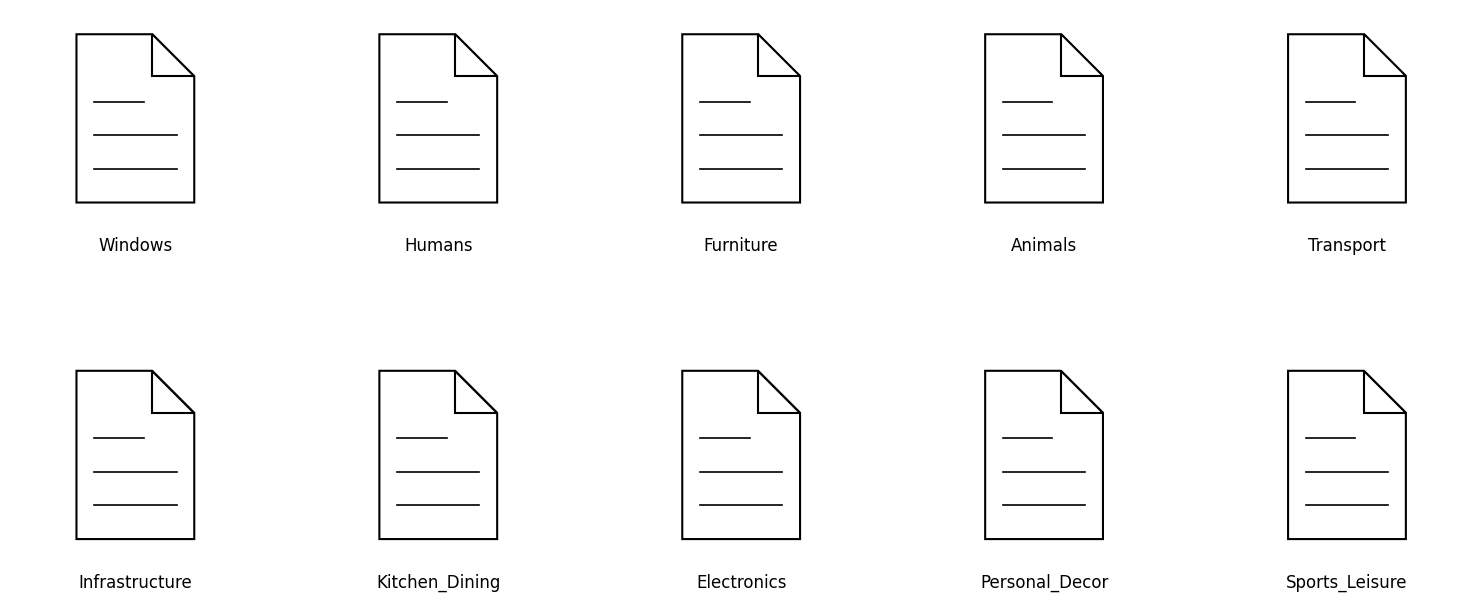

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. 填入你指定的 10 个类别名称
filenames = [
    "Windows",
    "Humans",
    "Furniture",
    "Animals",
    "Transport",
    "Infrastructure",
    "Kitchen_Dining",
    "Electronics",
    "Personal_Decor",
    "Sports_Leisure"
]

# 2. 创建画布
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(15, 6), facecolor='white') # 画布略微加宽，适应较长的单词如 Infrastructure
ax.axis('off') 

# 3. 画单个“折角文档”的函数
def draw_document_icon(ax, x_center, y_center, width=0.7, height=1.0, fold_size=0.25):
    x = x_center - width / 2
    y = y_center - height / 2
    
    # 主体
    body_points = [
        (x, y), 
        (x, y + height), 
        (x + width - fold_size, y + height), 
        (x + width, y + height - fold_size), 
        (x + width, y)
    ]
    body = patches.Polygon(body_points, closed=True, fill=True, 
                           facecolor='white', edgecolor='black', linewidth=1.5, zorder=2)
    ax.add_patch(body)
    
    # 折角
    fold_points = [
        (x + width - fold_size, y + height), 
        (x + width - fold_size, y + height - fold_size), 
        (x + width, y + height - fold_size)
    ]
    fold = patches.Polygon(fold_points, closed=True, fill=True, 
                           facecolor='white', edgecolor='black', linewidth=1.5, zorder=3)
    ax.add_patch(fold)
    
    # 内部横线
    line_margin_x = 0.15 * width
    line_spacing = height / 5
    for i in range(1, 4):
        line_y = y + i * line_spacing
        current_max_x = (x + width - line_margin_x) if i < 3 else (x + width - fold_size - 0.05)
        ax.plot([x + line_margin_x, current_max_x], [line_y, line_y], 
                color='black', linewidth=1.2, zorder=4)

# 4. 循环排版布局：2 行 x 5 列
columns = 5
rows = 2
x_spacing = 1.8 # 横向间距加大，给较长的名字留出充足呼吸空间
y_spacing = 2.0

for index, name in enumerate(filenames):
    col = index % columns
    row = index // columns
    
    x_pos = col * x_spacing
    y_pos = -row * y_spacing
    
    draw_document_icon(ax, x_pos, y_pos)
    
    # 添加真实的分类名称
    ax.text(x_pos, y_pos - 0.7, name, 
            ha='center', va='top', fontsize=12, family='sans-serif', color='black')

# 5. 调整并展示
ax.set_aspect('equal') 
ax.autoscale_view()    
plt.tight_layout()
plt.show()

# 想要保存的话，取消下面这行的注释
# plt.savefig("twin_city_dataset_icons.png", dpi=300, bbox_inches='tight', transparent=True)